<h1> Final Project: Cryptocurrency Return Prediction </h1>

<h2> Exercise 1: Data Exploration</h2>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, r2_score, mean_squared_error
import scipy.stats
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [2]:
data = pd.read_csv("BTC_daily_historical.csv")
print(data.describe())
print(50*"-")
print(data.info())
data.dropna(inplace=True)
data["date"] = pd.to_datetime(data["date"])

               open         close        volume          high           low  \
count   3987.000000   3987.000000  3.987000e+03   3987.000000   3987.000000   
mean   17717.745815  17740.647510  1.700194e+10  18119.554536  17300.833438   
std    20784.761185  20818.644318  1.964630e+10  21251.079054  20312.065879   
min      176.897003    178.102997  2.857830e+06    211.731003    171.509995   
25%      705.082001    705.037506  9.604215e+07    716.576019    697.131012   
50%     8549.470909   8562.454050  1.228464e+10   8726.796760   8273.572887   
75%    29041.107415  29060.921365  2.795070e+10  29442.301440  28663.461045   
max    99006.742270  98997.662080  3.509680e+11  99655.501080  97232.893120   

         market cap  
count  3.987000e+03  
mean   3.368993e+11  
std    4.056019e+11  
min    2.444379e+09  
25%    1.048527e+10  
50%    1.499140e+11  
75%    5.585695e+11  
max    1.958950e+12  
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
R

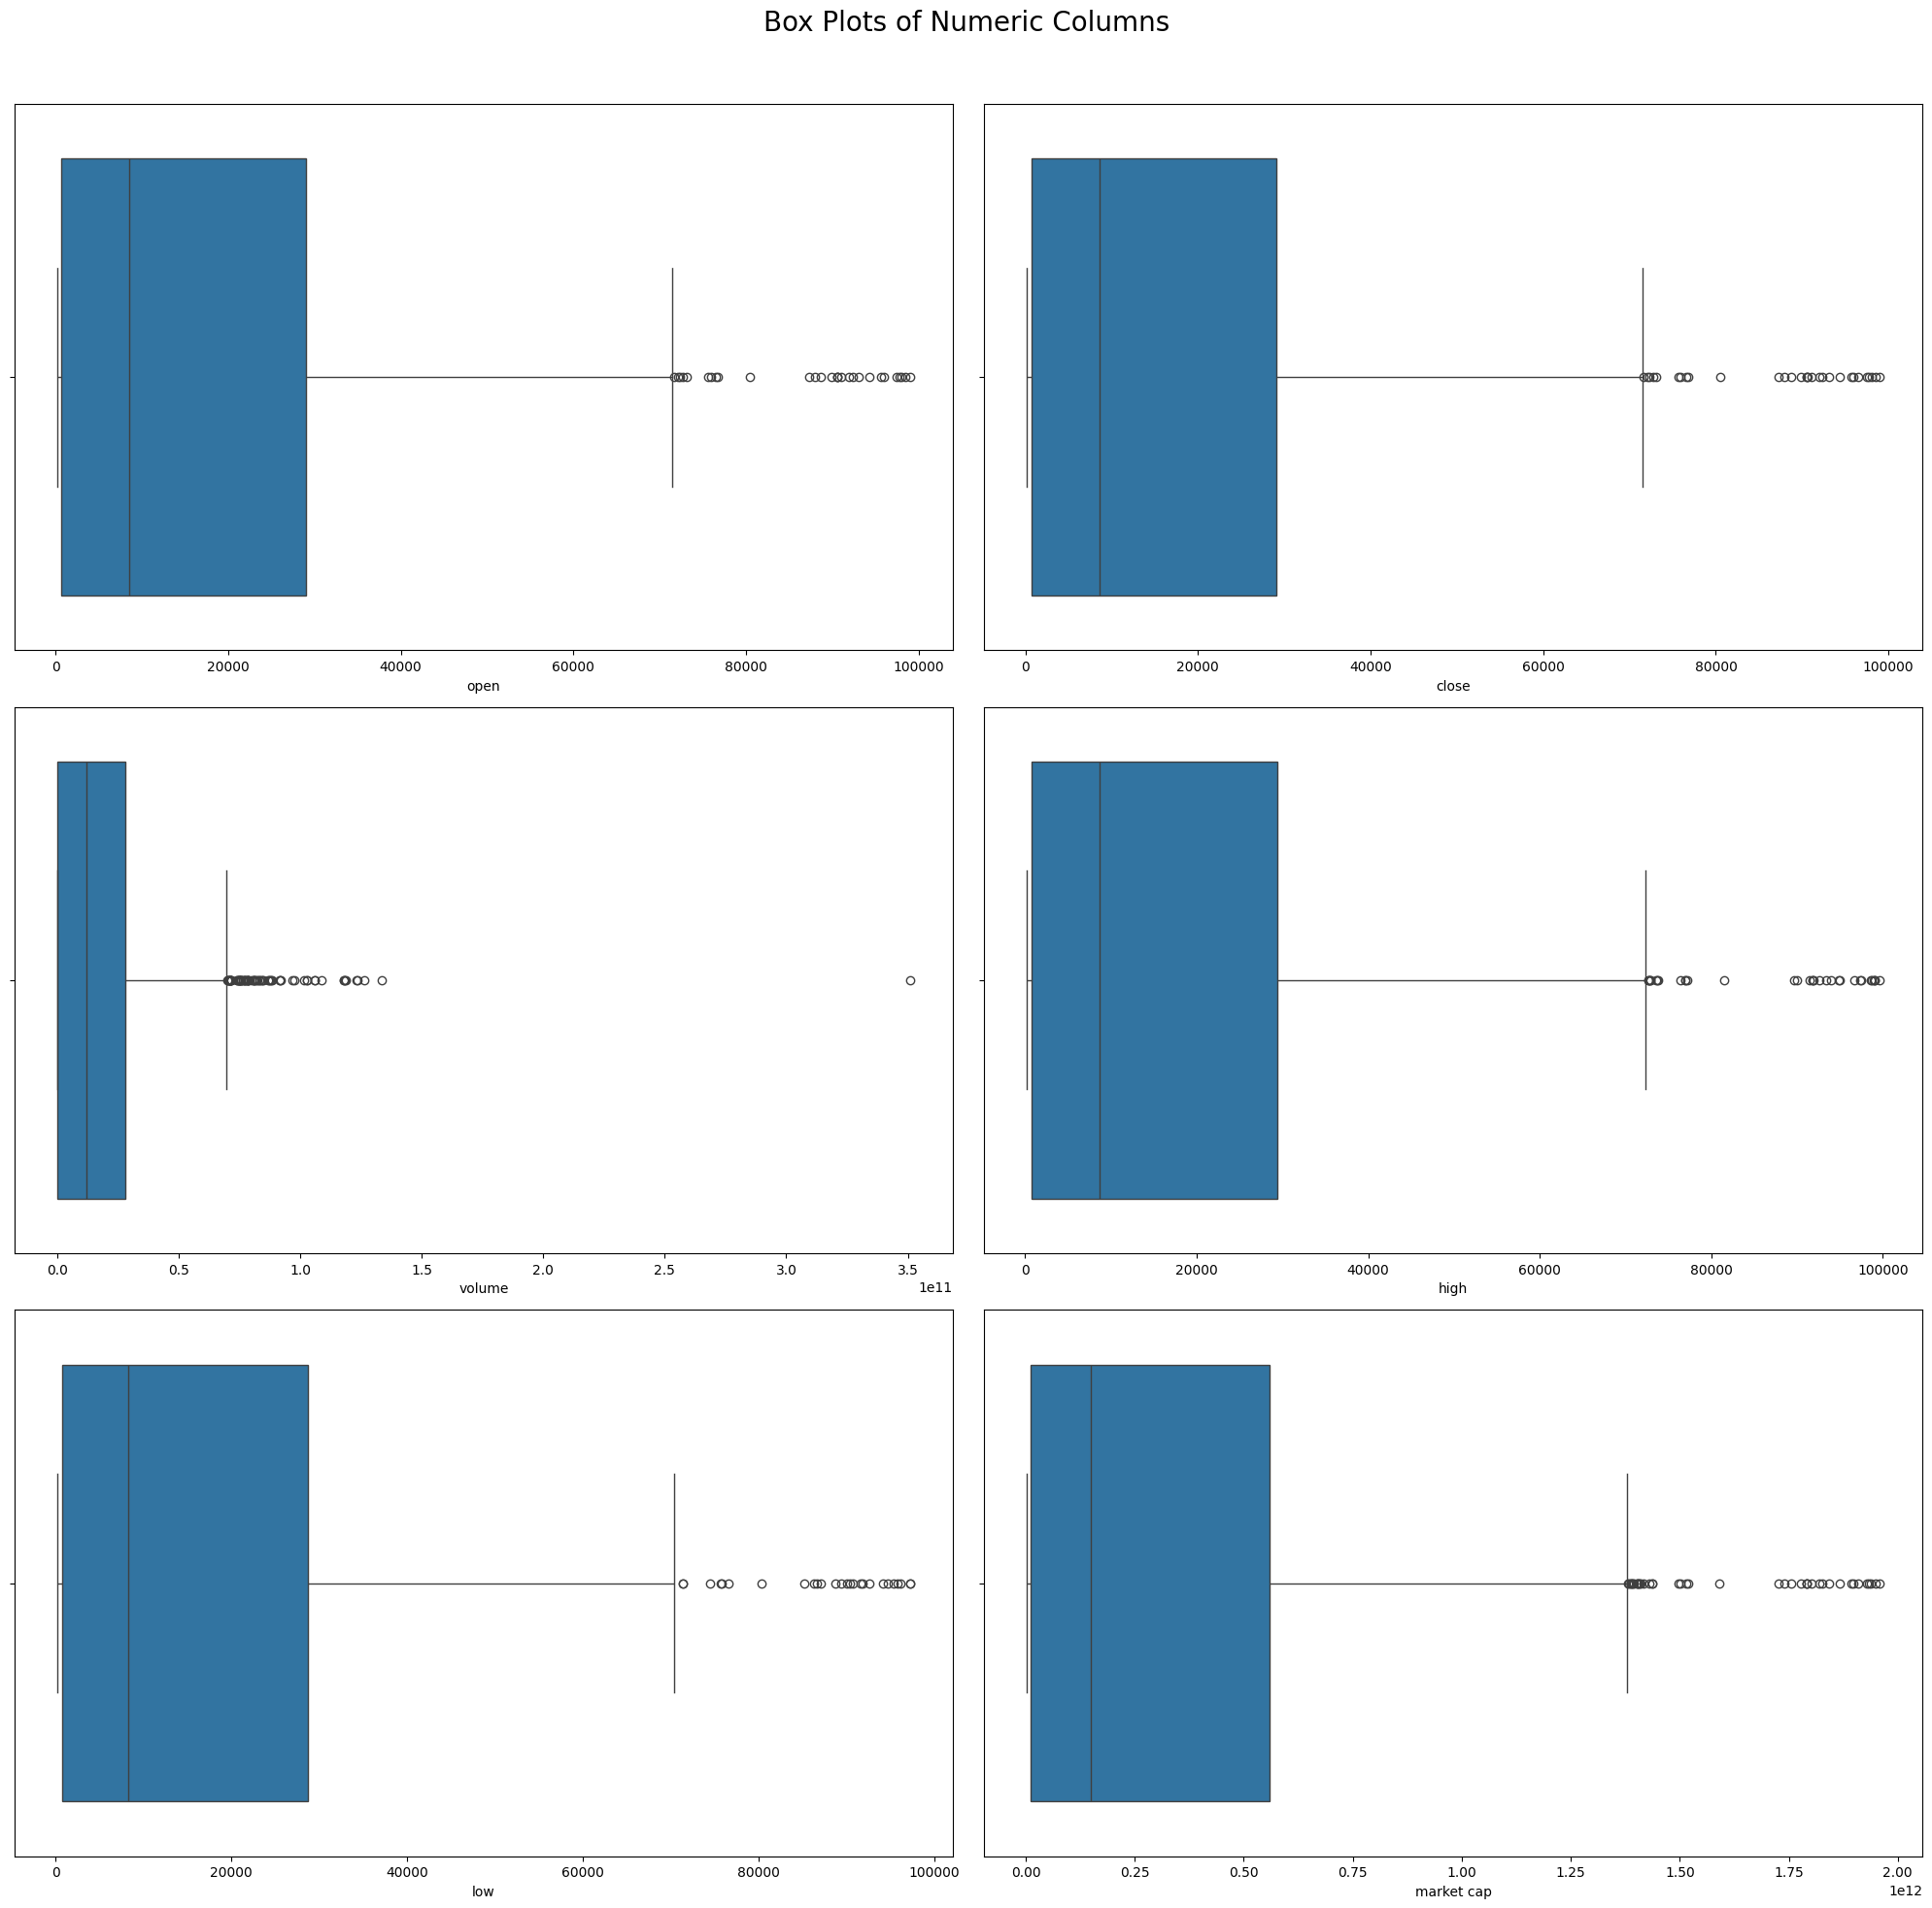

In [3]:
columns = data.select_dtypes(include="float").columns.to_list()

fig, axes = plt.subplots(int(len(columns)//2), 2, figsize=(20, 20))  
fig.suptitle("Box Plots of Numeric Columns", fontsize=20) 
axes = axes.flatten() 
for index, col in enumerate(columns):  
    sns.boxplot(data=data, x=col, ax=axes[index])  # Use correct syntax


plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

<Figure size 1000x500 with 0 Axes>

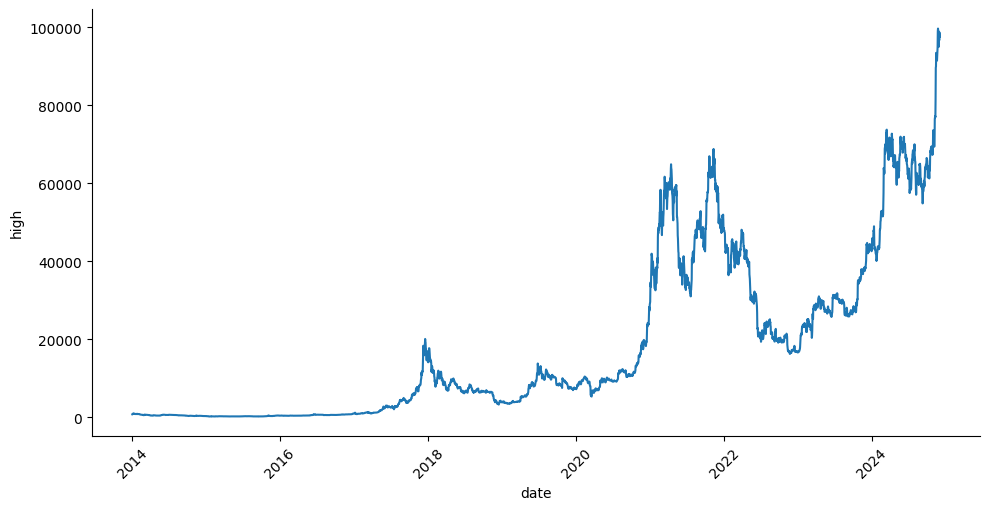

In [4]:
fig = plt.figure(figsize=(10,5))
sns.relplot(x="date", y="high", kind="line", data=data, height=5, aspect=2)
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

<h2> Exercise 2: Predictors/Factors </h2>

<h3> Size </h3>

In [4]:
data["week"] = data["date"].dt.to_period("W")

last_day_mcap = data.groupby("week").last()["market cap"]
log_last_day_mcap = np.log(last_day_mcap)
data = data.merge(log_last_day_mcap, on="week", suffixes=(None, "_MCAP"))

last_day_price = data.groupby("week").last()["close"]
log_last_day_price = np.log(last_day_price)
data = data.merge(log_last_day_price, on="week", suffixes=(None, "_PRC"))

max_day_price = data.groupby("week").max()["close"]
data = data.merge(max_day_price, on="week", suffixes=(None, "_MAXDPRC"))

#print(data.head(15))

/var/folders/sc/fn7t0bc17xsbfl68lnhstkp00000gn/T/ipykernel_92107/2848760311.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  data["week"] = data["date"].dt.to_period("W")


<h3> Mom </h3>

In [5]:
data["r_1"] = data["close"].diff(6)
data["r_2"] = data["close"].diff(13)
data["r_3"] = data["close"].diff(20)
data["r_4"] = data["close"].diff(27)
data["r_4_1"] = data["r_4"] - data["r_1"]

<h3> Volume </h3>

In [6]:
mean_vol = data.groupby("week")["volume"].mean()
log_mean_vol = np.log(mean_vol)
data = data.merge(log_mean_vol, on="week", suffixes=(None, "PRCVOL"))

std_vol = data.groupby("week")["volume"].std()
log_std_vol = np.log(std_vol)
data = data.merge(log_std_vol, on="week", suffixes=(None, "STDPRCVOL"))


In [7]:
data["diff"] = abs(data["close"].diff(-1)) / data["close"]

a = data.groupby("week")["diff"].mean()
data = data.merge(a, on="week", suffixes=(None, "_Step"))
data["DAMIHUD"] = data["diff_Step"] / data["volumePRCVOL"]
data.drop(["diff", "diff_Step"], axis=1, inplace=True)


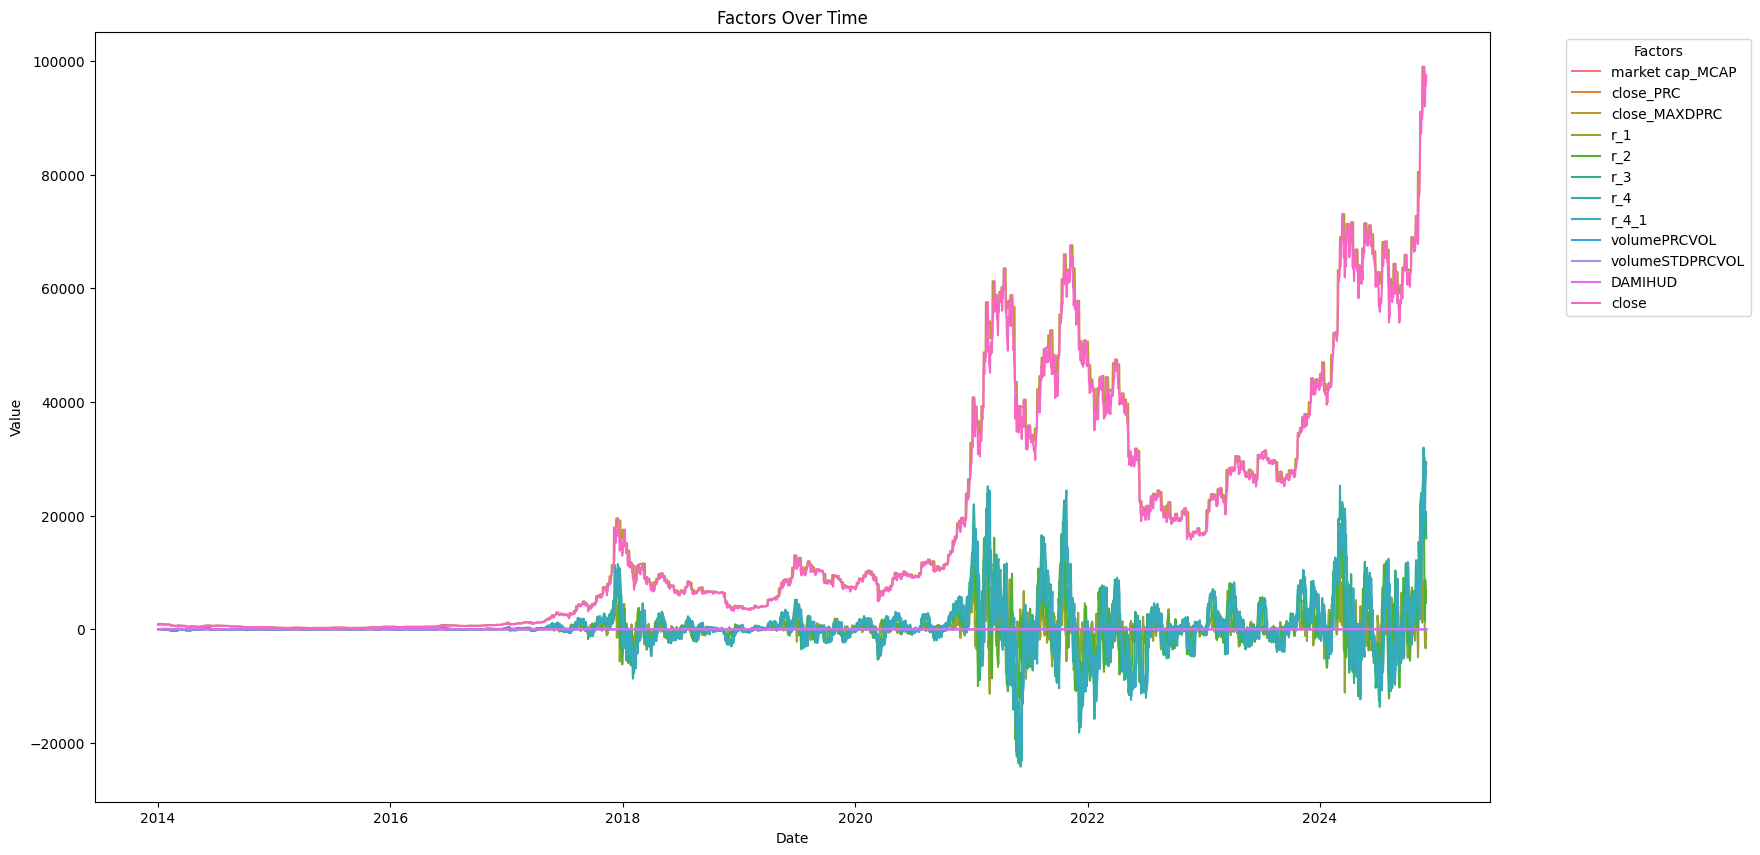

In [8]:
df_factors_exclude_seven = data[["market cap_MCAP", "close_PRC", "close_MAXDPRC", 
                     "r_1", "r_2", "r_3", "r_4", "r_4_1", 
                     "volumePRCVOL", "volumeSTDPRCVOL", "DAMIHUD", "close", "date"]]
df_melted = df_factors_exclude_seven.melt(id_vars=["date"], var_name="Factor", value_name="Value")

fig = plt.figure(figsize=(18, 10))
sns.lineplot(data=df_melted, x="date", y="Value", hue="Factor")

plt.title("Factors Over Time")
plt.xlabel("Date")
plt.ylabel("Value")

plt.legend(title="Factors", bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.show()

<h2> Exercise 3 </h2>

In [8]:
data["7d_return"] = -1* (data["close"].diff(-6) / data["close"])

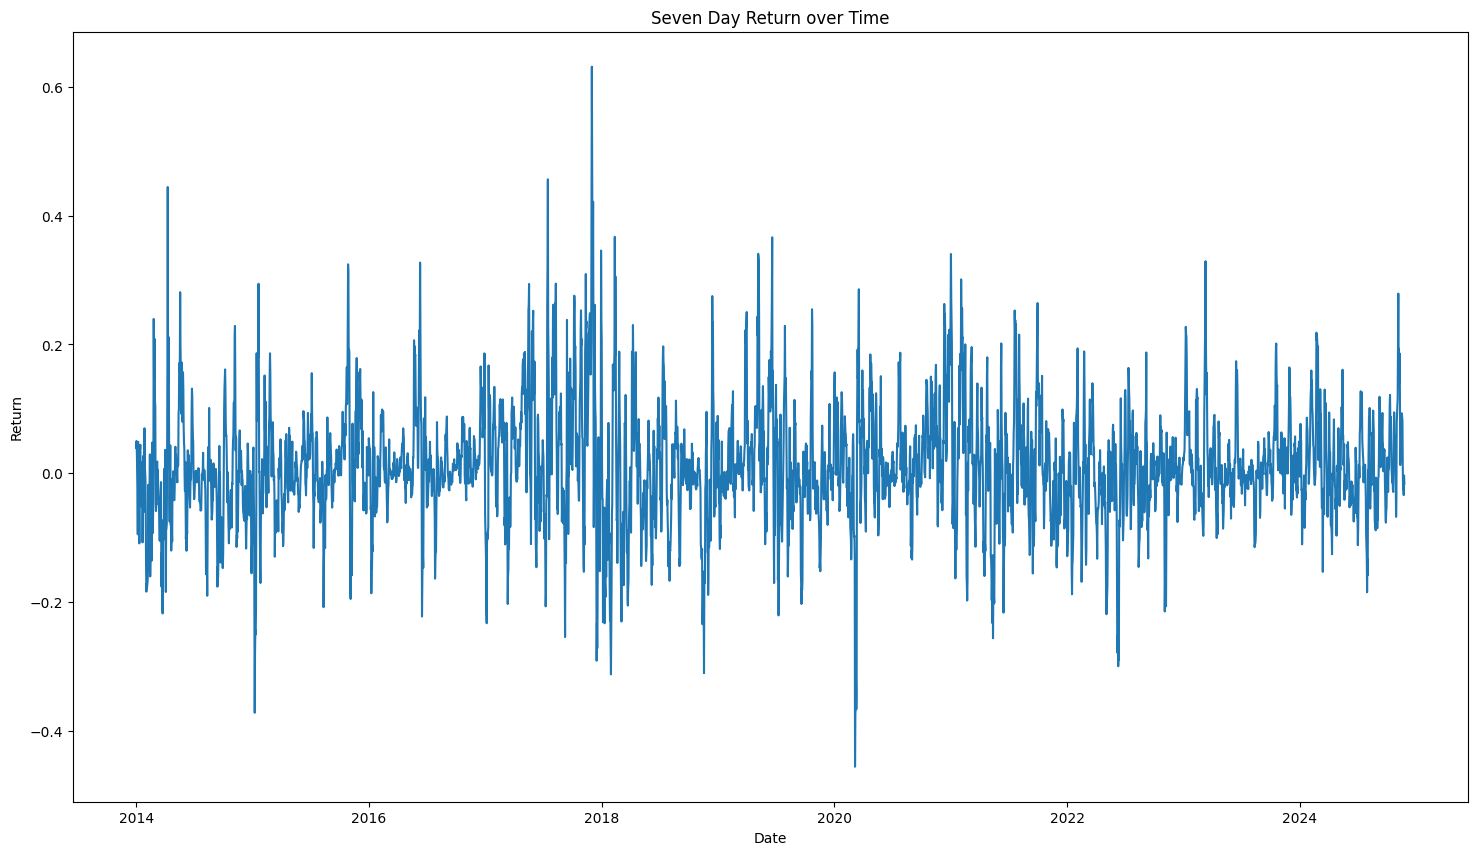

In [11]:
fig = plt.figure(figsize=(18, 10))
sns.lineplot(data=data, x="date", y="7d_return")

plt.title("Seven Day Return over Time")
plt.xlabel("Date")
plt.ylabel("Return")
plt.show()

<h2> Exercise 4 </h2>

In [10]:
df_price_vol = data.copy(deep=True)
sample = df_price_vol[df_price_vol["date"] <= "2022-12-31 00:00:00+00:00"]
out_of_sample = df_price_vol[df_price_vol["date"] > "2022-12-31 00:00:00+00:00"]

sample = sample[["open", "close", "high", "low", "volume", "7d_return"]]

out_of_sample = out_of_sample[["open", "close", "high", "low", "volume", "7d_return"]]

sample.dropna(inplace=True)
out_of_sample.dropna(inplace=True)

y= sample["7d_return"]
X = sample.drop(["7d_return"], axis=1)
y_test = out_of_sample["7d_return"]
X_test = out_of_sample.drop("7d_return", axis=1)

# Time Series Split (5 folds)
tscv = TimeSeriesSplit(n_splits=5)
# Define multiple scoring metrics
scoring = {
    "MSE": make_scorer(mean_squared_error, greater_is_better=False),
    "R2": make_scorer(r2_score)
}

In [11]:
estimators = {}
for i, (train_index, test_index) in enumerate(tscv.split(X)):
    pipeline = Pipeline([
    ("scaler", StandardScaler()),  
    ("model", LinearRegression())
    ])
    pipeline.fit(X.iloc[train_index], y.iloc[train_index])
    estimators[pipeline.score(X.iloc[test_index], y.iloc[test_index])] = pipeline

best_model_mlr = estimators[max(estimators.keys())]
print(list(estimators.keys()))
print(max(list(estimators.keys())), min(list(estimators.keys())), np.mean(list(estimators.keys())), np.median(list(estimators.keys())))
print("R2 oos: ", best_model_mlr.score(X_test, y_test))

[-0.25634543232790574, -73.90762257608561, -5.613348712338459, -0.1789723654771922, -0.025018993440447446]
-0.025018993440447446 -73.90762257608561 -15.996261615933923 -0.25634543232790574
R2 oos:  -0.12628476661462096


In [12]:
# Define pipeline: Scaling + Ridge
pipeline = Pipeline([
    ("scaler", StandardScaler()),  
    ("model", Ridge())  # Ridge regression (L2-regularized)
])

# Define hyperparameter grid (alpha is the regularization strength)
param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}


# Perform GridSearchCV with TimeSeriesSplit
grid_search = GridSearchCV(
    pipeline, param_grid, cv=tscv, scoring=scoring, refit="MSE", verbose=2, n_jobs=-1
)

# Fit the model
grid_search.fit(X, y)

# Extract best parameters and scores
best_params = grid_search.best_params_
best_mse = -grid_search.best_score_  # Convert negative MSE back to positive
best_r2 = grid_search.cv_results_["mean_test_R2"][grid_search.best_index_]  # Correctly fetch R²
best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)
print("Best Score (MSE):", best_mse)
print("Best Score (R²):", best_r2)
print("R2 oos: ", best_model.score(X_test, y_test))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END .................................model__alpha=0.001; total time=   0.0s
[CV] END .................................model__alpha=0.001; total time=   0.0s
[CV] END .................................model__alpha=0.001; total time=   0.0s
[CV] END ..................................model__alpha=0.01; total time=   0.0s
[CV] END ..................................model__alpha=0.01; total time=   0.0s
[CV] END ...................................model__alpha=0.1; total time=   0.0s
[CV] END ...................................model__alpha=0.1; total time=   0.0s
[CV] END ...................................model__alpha=0.1; total time=   0.0s
[CV] END ...................................model__alpha=0.1; total time=   0.0s
[CV] END .................................model__alpha=0.001; total time=   0.0s
[CV] END ...................................model__alpha=0.1; total time=   0.0s
[CV] END .................................model__

In [13]:
# Define pipeline: Scaling + Random Forest
pipeline_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Define hyperparameter grid
param_grid_rf = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5, 10]
}

# Perform GridSearchCV with TimeSeriesSplit
grid_search_rf = GridSearchCV(
    pipeline_rf, param_grid_rf, cv=tscv, scoring=scoring, refit="MSE", verbose=2, n_jobs=-1
)

# Fit the model
grid_search_rf.fit(X, y)

# Extract best parameters and scores
best_params_rf = grid_search_rf.best_params_
best_mse_rf = -grid_search_rf.best_score_  # Convert negative MSE back to positive
best_r2_rf = grid_search_rf.cv_results_["mean_test_R2"][grid_search_rf.best_index_]
best_model_rf = grid_search_rf.best_estimator_

print("Best RF Parameters:", best_params_rf)
print("Best RF Score (MSE):", best_mse_rf)
print("Best RF Score (R²):", best_r2_rf)
print("R2 oos: ", best_model_rf.score(X_test, y_test))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.2s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.3s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.4s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.5s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.6s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.7s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.7s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.8s
[CV] END model__max_depth=None, model__min_samples_split=5, model__n_estimators=50; total time=   0.2s
[CV] END

In [14]:
# Define pipeline: Scaling + SVM
pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR())
])

# Define hyperparameter grid
param_grid_svm = {
    "model__C": [0.1, 1, 10],
    "model__epsilon": [0.01, 0.1, 0.5],
    "model__kernel": ["linear", "rbf", "poly"]
}

# Perform GridSearchCV with TimeSeriesSplit
grid_search_svm = GridSearchCV(
    pipeline_svm, param_grid_svm, cv=tscv, scoring=scoring, refit="MSE", verbose=2, n_jobs=-1
)

# Fit the model
grid_search_svm.fit(X, y)

# Extract best parameters and scores
best_params_svm = grid_search_svm.best_params_
best_mse_svm = -grid_search_svm.best_score_  # Convert negative MSE back to positive
best_r2_svm = grid_search_svm.cv_results_["mean_test_R2"][grid_search_svm.best_index_]
best_model_svm = grid_search_svm.best_estimator_

print("Best SVM Parameters:", best_params_svm)
print("Best SVM Score (MSE):", best_mse_svm)
print("Best SVM Score (R²):", best_r2_svm)
print("R2 oos: ", best_model_svm.score(X_test, y_test))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=linear; total time=   0.0s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=rbf; total time=   0.0s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=linear; total time=   0.0s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=poly; total time=   0.0s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=rbf; total time=   0.1s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=linear; total time=   0.1s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=rbf; total time=   0.1s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=linear; total time=   0.2s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=poly; total time=   0.1s
[CV] END model__C=0.1, model__epsilon=0.1, model__kernel=linear; total time=   0.0s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=rbf; total time=   0.2s
[CV] END model__C=0.

<h2> Exercise 5 </h2>

In [ ]:
df_price_vol = data.copy(deep=True)
sample = df_price_vol[df_price_vol["date"] <= "2022-12-31 00:00:00+00:00"]
out_of_sample = df_price_vol[df_price_vol["date"] > "2022-12-31 00:00:00+00:00"]

sample = sample[["market cap_MCAP", "close_PRC", "close_MAXDPRC", 
                     "r_1", "r_2", "r_3", "r_4", "r_4_1", 
                     "volumePRCVOL", "volumeSTDPRCVOL", "DAMIHUD", "7d_return"]]

out_of_sample = out_of_sample[["market cap_MCAP", "close_PRC", "close_MAXDPRC", 
                     "r_1", "r_2", "r_3", "r_4", "r_4_1", 
                     "volumePRCVOL", "volumeSTDPRCVOL", "DAMIHUD", "7d_return"]]

sample.dropna(inplace=True)
out_of_sample.dropna(inplace=True)

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

y= sample["7d_return"]
X = sample.drop(["7d_return"], axis=1)
y_test = out_of_sample["7d_return"]
X_test = out_of_sample.drop("7d_return", axis=1)

In [10]:
estimators = {}
for i, (train_index, test_index) in enumerate(tscv.split(X)):
    pipeline = Pipeline([
    ("scaler", StandardScaler()),  
    ("model", LinearRegression())
    ])
    pipeline.fit(X.iloc[train_index], y.iloc[train_index])
    estimators[pipeline.score(X.iloc[test_index], y.iloc[test_index])] = pipeline

best_model_mlr = estimators[max(estimators.keys())]
print(list(estimators.keys()))
print(max(list(estimators.keys())), min(list(estimators.keys())), np.mean(list(estimators.keys())), np.median(list(estimators.keys())))
print("R2 oos: ", best_model_mlr.score(X_test, y_test))

[-0.18246168200470692, -672.8712584203093, -0.17803969369322914, -2.425124044820451, -0.1534407916629157]
-0.1534407916629157 -672.8712584203093 -135.16206492649812 -0.18246168200470692
R2 oos:  -0.15466092333998693


In [12]:
# Define pipeline: Scaling + Ridge
pipeline = Pipeline([
    ("scaler", StandardScaler()),  
    ("model", Ridge())  # Ridge regression (L2-regularized)
])

# Define hyperparameter grid (alpha is the regularization strength)
param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]
}

# Define multiple scoring metrics
scoring = {
    "MSE": make_scorer(mean_squared_error, greater_is_better=False),
    "R2": make_scorer(r2_score)
}

# Perform GridSearchCV with TimeSeriesSplit
grid_search = GridSearchCV(
    pipeline, param_grid, cv=tscv, scoring=scoring, refit="MSE", verbose=2, n_jobs=-1
)

# Fit the model
grid_search.fit(X, y)

# Extract best parameters and scores
best_params = grid_search.best_params_
best_mse = -grid_search.best_score_  # Convert negative MSE back to positive
best_r2 = grid_search.cv_results_["mean_test_R2"][grid_search.best_index_]  # Correctly fetch R²
best_model = grid_search.best_estimator_

print("Best Parameters:", best_params)
print("Best Score (MSE):", best_mse)
print("Best Score (R²):", best_r2)
print("R2 oos: ", best_model.score(X_test, y_test))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END .................................model__alpha=0.001; total time=   0.0s
[CV] END .................................model__alpha=0.001; total time=   0.0s
[CV] END .................................model__alpha=0.001; total time=   0.0s
[CV] END .................................model__alpha=0.001; total time=   0.0s
[CV] END .................................model__alpha=0.001; total time=   0.0s
[CV] END ..................................model__alpha=0.01; total time=   0.0s
[CV] END ..................................model__alpha=0.01; total time=   0.0s
[CV] END ..................................model__alpha=0.01; total time=   0.0s
[CV] END ..................................model__alpha=0.01; total time=   0.0s
[CV] END ..................................model__alpha=0.01; total time=   0.0s
[CV] END ...................................model__alpha=0.1; total time=   0.0s
[CV] END ...................................model

In [13]:
# Define pipeline: Scaling + SVM
pipeline_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR())
])

# Define hyperparameter grid
param_grid_svm = {
    "model__C": [0.1, 1, 10],
    "model__epsilon": [0.01, 0.1, 0.5],
    "model__kernel": ["linear", "rbf", "poly"]
}

# Perform GridSearchCV with TimeSeriesSplit
grid_search_svm = GridSearchCV(
    pipeline_svm, param_grid_svm, cv=tscv, scoring=scoring, refit="MSE", verbose=2, n_jobs=-1
)

# Fit the model
grid_search_svm.fit(X, y)

# Extract best parameters and scores
best_params_svm = grid_search_svm.best_params_
best_mse_svm = -grid_search_svm.best_score_  # Convert negative MSE back to positive
best_r2_svm = grid_search_svm.cv_results_["mean_test_R2"][grid_search_svm.best_index_]
best_model_svm = grid_search_svm.best_estimator_

print("Best SVM Parameters:", best_params_svm)
print("Best SVM Score (MSE):", best_mse_svm)
print("Best SVM Score (R²):", best_r2_svm)
print("R2 oos: ", best_model_svm.score(X_test, y_test))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=linear; total time=   0.0s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=rbf; total time=   0.0s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=linear; total time=   0.1s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=rbf; total time=   0.1s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=poly; total time=   0.0s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=linear; total time=   0.1s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=rbf; total time=   0.1s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=poly; total time=   0.1s
[CV] END model__C=0.1, model__epsilon=0.1, model__kernel=linear; total time=   0.0s
[CV] END model__C=0.1, model__epsilon=0.01, model__kernel=linear; total time=   0.2s
[CV] END model__C=0.1, model__epsilon=0.1, model__kernel=linear; total time=   0.0s
[CV] END model__C=

In [14]:
# Define pipeline: Scaling + Random Forest
pipeline_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
])

# Define hyperparameter grid
param_grid_rf = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5, 10]
}

# Perform GridSearchCV with TimeSeriesSplit
grid_search_rf = GridSearchCV(
    pipeline_rf, param_grid_rf, cv=tscv, scoring=scoring, refit="MSE", verbose=2, n_jobs=-1
)

# Fit the model
grid_search_rf.fit(X, y)

# Extract best parameters and scores
best_params_rf = grid_search_rf.best_params_
best_mse_rf = -grid_search_rf.best_score_  # Convert negative MSE back to positive
best_r2_rf = grid_search_rf.cv_results_["mean_test_R2"][grid_search_rf.best_index_]
best_model_rf = grid_search_rf.best_estimator_

print("Best RF Parameters:", best_params_rf)
print("Best RF Score (MSE):", best_mse_rf)
print("Best RF Score (R²):", best_r2_rf)
print("R2 oos: ", best_model_rf.score(X_test, y_test))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.2s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.4s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.5s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.7s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=100; total time=   0.8s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   0.9s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=50; total time=   1.1s
[CV] END model__max_depth=None, model__min_samples_split=2, model__n_estimators=200; total time=   0.7s
[CV] END model__max_depth=None, model__min_samples_split=5, model__n_estimators=50; total time=   0.1s
[CV] END

<h3> Compare with "normal" CV </h3>

In [15]:
rf = RandomForestRegressor(random_state=42, n_estimators=100)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42)
rf.fit(X_train, y_train)
rf_cv_score_train = cross_val_score(rf, X_train, y_train, cv=5)
rf_cv_score_all = cross_val_score(rf, X, y, cv=5)
rf_score = rf.score(X_test, y_test)
print(rf_score)
print(rf_cv_score_train)
print(rf_cv_score_all)

0.5591467915240713
[0.50466235 0.50679646 0.53934623 0.53100503 0.52856273]
[-0.42984381 -0.21264002 -0.21779667 -0.37096894 -1.07599178]


<h2> Statistical Tests for Regression </h2>

In [16]:
predictor_df = data[["market cap_MCAP", "close_PRC", "close_MAXDPRC", 
                     "r_1", "r_2", "r_3", "r_4", "r_4_1", 
                     "volumePRCVOL", "volumeSTDPRCVOL", "DAMIHUD", "7d_return", "date"]]
predictor_df = predictor_df.dropna()

X = predictor_df.drop("7d_return", axis=1)
y = predictor_df[["7d_return", "date"]]
X_train = X[X["date"] <= "2022-12-31 00:00:00+00:00"].drop("date", axis=1)
X_test = X[X["date"] > "2022-12-31 00:00:00+00:00"].drop("date", axis=1)
y_train = y[y["date"] <= "2022-12-31 00:00:00+00:00"].drop("date", axis=1)
y_test = y[y["date"] > "2022-12-31 00:00:00+00:00"].drop("date", axis=1)
X = X.drop("date", axis=1)
y = y.drop("date", axis=1)
mlr_stats = LinearRegression()
mlr_stats.fit(X_train, y_train)
mlr_stats_score = mlr_stats.score(X_test, y_test)
mlr_stats_scores_is = cross_val_score(estimator=mlr_stats, X=X_train, y=y_train, cv=5)
mlr_stats_scores_oos = cross_val_score(estimator=mlr_stats, X=X_test, y=y_test, cv=5)
res_train = mlr_stats.predict(X_train) - y_train
SSE = np.sum(np.square(res_train)).values
SSR = np.sum(np.square(mlr_stats.predict(X_train) - np.mean(y_train)))
n = len(y_train)
k = len(list(X_train))

In [17]:
F_value = (SSR/k) / (SSE/(n-k-1))
F_critical = scipy.stats.f.ppf(q=1-0.05, dfn=k, dfd= n-k-1)
if F_value < F_critical:
    print("F_value = " + str(F_value) + ", F_critical = " + str(F_critical) + " => Nullhypothesis not rejected, Regression is not significant")
elif F_value > F_critical:
    print("F_value = " + str(F_value) + ", F_critical = " + str(F_critical) + " => Nullhypothesis rejected, Regression is significant")

F_value = [8.8380422], F_critical = 1.7915896685952586 => Nullhypothesis rejected, Regression is significant


In [18]:
matrix = (SSE/(n-k-1)) * np.linalg.inv((X_train.T @ X_train))
significant_features = []
for index, p in enumerate(list(X_train)):
    t_value = mlr_stats.coef_[0, index] / np.sqrt(matrix[index][index])
    t_critical = scipy.stats.t.ppf(q=1-0.05, df=n-k-1)
    if t_value < t_critical:
        print("t_value = " + str(t_value) + ", t_critical = " + str(t_critical) + " => Nullhypothesis not rejected, " + str(p) + " is not significant")
    elif t_value > t_critical:
        print("t_value = " + str(t_value) + ", t_critical = " + str(t_critical) + " => Nullhypothesis rejected, " + str(p) + " is significant")
        significant_features.append(str(p))

X_train_significant = X_train[significant_features]
X_test_significant = X_test[significant_features]
mlr_stats_significant = LinearRegression()
mlr_stats_significant.fit(X_train_significant, y_train)
n_test = len(y_test)
k_significant = len(significant_features)
print("R2 adjusted oos with all features: " + str(1-(1-mlr_stats_score)*((n_test-1)/(n_test-k-1))) + ", R2 adjusted oos with only significant ones: " + str(1-(1-mlr_stats_significant.score(X_test_significant, y_test))*((n_test-1)/(n_test-k_significant-1))))
print("Significant features are: " + str(significant_features))

t_value = 286.91646971391725, t_critical = 1.645322902350296 => Nullhypothesis rejected, market cap_MCAP is significant
t_value = -62.316386816510665, t_critical = 1.645322902350296 => Nullhypothesis not rejected, close_PRC is not significant
t_value = -6.448303952204302, t_critical = 1.645322902350296 => Nullhypothesis not rejected, close_MAXDPRC is not significant
t_value = 0.10220316465531101, t_critical = 1.645322902350296 => Nullhypothesis not rejected, r_2 is not significant
t_value = -1.1796530375327001, t_critical = 1.645322902350296 => Nullhypothesis not rejected, r_3 is not significant
t_value = -4.637775954623681, t_critical = 1.645322902350296 => Nullhypothesis not rejected, volumePRCVOL is not significant
t_value = -0.03732832258547659, t_critical = 1.645322902350296 => Nullhypothesis not rejected, volumeSTDPRCVOL is not significant
t_value = 6.4723110620247075, t_critical = 1.645322902350296 => Nullhypothesis rejected, DAMIHUD is significant
R2 adjusted oos with all featu

/var/folders/sc/fn7t0bc17xsbfl68lnhstkp00000gn/T/ipykernel_92107/224972998.py:4: RuntimeWarning: invalid value encountered in sqrt
  t_value = mlr_stats.coef_[0, index] / np.sqrt(matrix[index][index])


<h3> Residual plot </h3>

Text(0.5, 1.0, 'test residuals significant features')

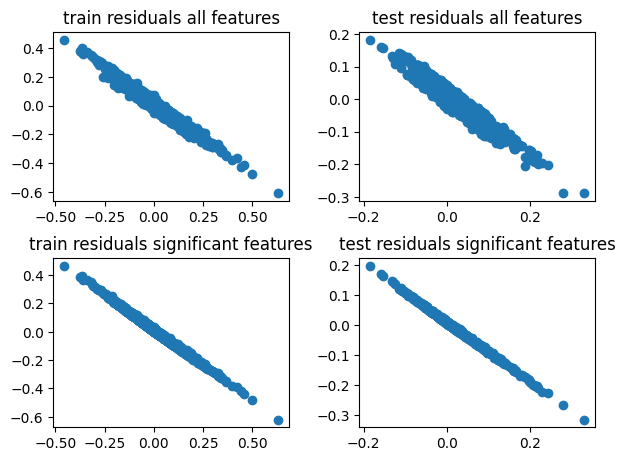

In [19]:
fig, ax = plt.subplots(2,2)
plt.tight_layout(pad=2.0)
ax[0, 0].scatter(y_train, res_train)
ax[0, 1].scatter(y_test, mlr_stats.predict(X_test) - y_test)
ax[1, 0].scatter(y_train, mlr_stats_significant.predict(X_train_significant) - y_train)
ax[1, 1].scatter(y_test, mlr_stats_significant.predict(X_test_significant) - y_test)
ax[0, 0].set_title("train residuals all features")
ax[0, 1].set_title("test residuals all features")
ax[1, 0].set_title("train residuals significant features")
ax[1, 1].set_title("test residuals significant features")

<h3> Exploring with VIF</h3>

In [20]:
""""
getting RuntimeWarning: invalid value encountered in sqrt t_value = mlr.coef_[index] / np.sqrt(matrix[index][index])
means some values of the matrix are negative 
"""
print(SSE) # See if SSE is the problem
# SSE is positive so the matrix has to be the problem
print(np.linalg.cond(matrix)) # cond=2.97 which is fine
print(min(np.diag(X_train.T @ X_train))) # check if any negative elements on the diagonal of XX
print(np.diag(np.linalg.inv(X_train.T @ X_train))) # check if any negative elements on the diagonal of (XX)-1
# high multicollinearity between features
vif = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("VIF values:", vif)
X_vif = X
while max(vif) > 10:
    X_vif = X_vif.drop(X_vif.columns[vif.index(max(vif))], axis=1)
    vif = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

print(list(X_vif))

[28.5580603]
2.7300290603015286e+17
0.006318809614793383
[ 1.39081888e-04  2.56914943e-03  5.36839282e-12 -6.41628549e+04
  1.52638206e-10  1.52377140e-10 -6.41628549e+04 -6.41628549e+04
  1.77310165e-03  1.53483808e-03  6.79563805e+02]
VIF values: [330.47669379567844, 595.7481094157484, 10.375873882923125, inf, 4.134723534944666, 6.603140391650287, inf, inf, 2488.398275724727, 2088.87625901167, 4.111414100718768]
['market cap_MCAP', 'close_MAXDPRC', 'r_2', 'r_3', 'r_4_1', 'DAMIHUD']


/Users/blk/Library/Python/3.9/lib/python/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


<h3> Testing for significance after VIF filtering </h3>

In [21]:
X_vif_train = X_vif[:n]
X_vif_test = X_vif[n:]
k_vif = len(list(X_vif_train))
mlr_vif = LinearRegression()
mlr_vif.fit(X_vif_train, y_train)
SSE_vif = np.sum(np.square(mlr_vif.predict(X_vif_train) - y_train)).values
matrix_vif = (SSE/(n-k_vif-1)) * np.linalg.inv((X_vif_train.T @ X_vif_train))
significant_features_vif = []
for index, p in enumerate(list(X_vif)):
    t_value = mlr_vif.coef_[0, index] / np.sqrt(matrix_vif[index][index])
    t_critical = scipy.stats.t.ppf(q=1-0.05, df=n-k-1)
    if t_value < t_critical:
        print("t_value = " + str(t_value) + ", t_critical = " + str(t_critical) + " => Nullhypothesis not rejected, " + str(p) + " is not significant")
    elif t_value > t_critical:
        print("t_value = " + str(t_value) + ", t_critical = " + str(t_critical) + " => Nullhypothesis rejected, " + str(p) + " is significant")
        significant_features_vif.append(str(p))

X_train_significant_vif = X_vif_train[significant_features_vif]
X_test_significant_vif = X_vif_test[significant_features_vif]
mlr_stats_significant_vif = LinearRegression()
mlr_stats_significant_vif.fit(X_train_significant_vif, y_train)
n_test = len(y_test)
k_significant_vif = len(significant_features_vif)
print(k_significant_vif)
print("R2 adjusted oos with all features: " + str(1-(1-mlr_stats_score)*((n_test-1)/(n_test-k-1))) + ", R2 adjusted oos with only significant ones: " + str(1-(1-mlr_stats_significant_vif.score(X_test_significant_vif, y_test))*((n_test-1)/(n_test-k_significant_vif-1))))
print("Significant features after VIF filtering are: " + str(significant_features_vif))

t_value = 47.793272590351286, t_critical = 1.645322902350296 => Nullhypothesis rejected, market cap_MCAP is significant
t_value = -8.633532955198552, t_critical = 1.645322902350296 => Nullhypothesis not rejected, close_MAXDPRC is not significant
t_value = 1.1876784640682976, t_critical = 1.645322902350296 => Nullhypothesis not rejected, r_2 is not significant
t_value = -0.36659418518929576, t_critical = 1.645322902350296 => Nullhypothesis not rejected, r_3 is not significant
t_value = 1.2872907291000086, t_critical = 1.645322902350296 => Nullhypothesis not rejected, r_4_1 is not significant
t_value = 3.2660556643746292, t_critical = 1.645322902350296 => Nullhypothesis rejected, DAMIHUD is significant
2
R2 adjusted oos with all features: -0.027416427191693904, R2 adjusted oos with only significant ones: -0.003244880103260517
Significant features after VIF filtering are: ['market cap_MCAP', 'DAMIHUD']


<h3> Time Series Split with significant and VIF filtered features </h3>

In [22]:
tscv_vif = TimeSeriesSplit(n_splits=round(len(y)/67)-1, gap=5, test_size=60)
mlr_vif_ts = LinearRegression()
scores_vif_ts = []
counter = 0
for i, (train_index, test_index) in enumerate(tscv_vif.split(X_vif)):
    counter += 1
    mlr_vif_ts.fit(X_vif.iloc[train_index], y.iloc[train_index])
    scores_vif_ts.append(mlr_vif_ts.score(X_vif.iloc[test_index], y.iloc[test_index]))
    

print(scores_vif_ts)
print("splits: " + str(counter))
print(max(scores_vif_ts), min(scores_vif_ts), np.mean(scores_vif_ts), np.median(scores_vif_ts))

[-0.8227827690977192, -0.186935349093458, 0.021320751928995185, -0.14609099548892268, -1.0553594427459942, -1.8836863198980476, 0.040813089497808486, -0.04262955572956373, -0.21642528645879966, -0.6819332475584403, -1.9490341824650663, -1.45798642300254, -5.204616053231962, -0.40867579036563106, -0.019145621173298544, -0.10114231701965437, -6.639959121176667, -0.0809925257726114, -1.0391916929396436, -0.04853114410096171, -0.8116840701266244, -0.3217297194158253, -0.2862133490921923, -0.038192921162895965, -0.5208283246408099, -0.6380134115275944, -0.12834792599728595, -0.004032881633597274, -0.12303700704703835, -0.03503181282814416, -0.06820585636602927, -0.10487191359956549, -0.14016615489104378, -2.1210230177728238, -2.5403984338774506, -0.9122814916780739, -0.8373894347895949, -0.0045283063308168, -0.08153692528151701, -0.027729195416824393, -0.027945958428794215, -0.039246429810240846, -0.3897853685189645, -0.01769645019523236, -0.30137672763313006, -0.15761809565860663, -0.05988

<h2> Exercise 7 </h2>

In [23]:
p0_buy_and_hold = data["close"].iloc[3287]
pT_buy_and_hold = data["close"].iloc[-1]
bitcoins_purchased = 100000 / p0_buy_and_hold
return_buy_and_hold = pT_buy_and_hold * (bitcoins_purchased)
track_buy_and_hold = data[["date", "close"]][3287:-6].dropna()
track_buy_and_hold["value"] = track_buy_and_hold["close"] * bitcoins_purchased
print(return_buy_and_hold)

580141.8857486378


In [24]:
def buy(cash, bitcoins, price):
    if cash <= 0:
        return cash, bitcoins
    elif cash > 0:
        new_bitcoins = cash / price 
        return 0, (bitcoins + new_bitcoins)
    

def sell(cash, bitcoins, price):
    if bitcoins <= 0:
        return cash, bitcoins
    elif bitcoins > 0:
        return (cash + (price * bitcoins)), 0

In [25]:
predictor_df = data[["market cap_MCAP", "close_PRC", "close_MAXDPRC", "r_1", "r_2", "r_3", "r_4", "r_4_1", "volumePRCVOL", "volumeSTDPRCVOL", "DAMIHUD", "7d_return", "close", "date"]]

sample = predictor_df[:3287]
sample = sample.dropna()
X_sample = sample.drop(["7d_return", "close", "date"], axis=1)
y_sample = sample["7d_return"]

out_of_sample = predictor_df[3287:]
out_of_sample = out_of_sample.dropna()
X_oos = out_of_sample.drop("7d_return", axis=1)
y_oos = out_of_sample["7d_return"]

tscv = TimeSeriesSplit(n_splits=5)
scoring = {
    "MSE": make_scorer(mean_squared_error, greater_is_better=False),
    "R2": make_scorer(r2_score)
}
best_models = {}

<h3> Random Forest </h3>

In [26]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('rf', RandomForestRegressor(random_state=42))  
])

param_grid = {
    "rf__n_estimators": [50, 100, 200],   
    "rf__max_depth": [5, 10, None],       
    "rf__min_samples_split": [2, 5, 10],  
    "rf__min_samples_leaf": [1, 2, 4]     
}


grid_search = GridSearchCV(
    pipeline, param_grid, cv=tscv, scoring=scoring, n_jobs=-1, verbose=2, refit="MSE"
)


grid_search.fit(X_sample, y_sample)


# Extract the best parameters from GridSearchCV
best_model_rf = grid_search.best_estimator_
best_params_rf = grid_search.best_params_
best_mse_rf = -grid_search.best_score_  # Convert negative MSE back to positive
best_r2_rf = grid_search.cv_results_["mean_test_R2"][grid_search.best_index_]
# Train a new pipeline with the best parameters
predictor = Pipeline([
    ('scaler', StandardScaler()),  
    ('rf', RandomForestRegressor(random_state=42, 
                                 n_estimators=best_params_rf["rf__n_estimators"],
                                 max_depth=best_params_rf["rf__max_depth"],
                                 min_samples_split=best_params_rf["rf__min_samples_split"],
                                 min_samples_leaf=best_params_rf["rf__min_samples_leaf"]))  
])

# Fit the new pipeline on the full dataset
predictor.fit(X_sample, y_sample)
best_models["rf"] = predictor
print("Best RF Parameters:", best_params_rf)
print("Best RF Score (MSE):", best_mse_rf)
print("Best R^2 Score:", best_r2_rf)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.1s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.2s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=100; total time=   0.2s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.2s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.3s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=100; total time=   0.3s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.4s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=100; total time=   0.5s
[CV] END rf__ma

<h3> Linear Regression </h3>

In [27]:
estimators = {}
for i, (train_index, test_index) in enumerate(tscv.split(X_sample)):
    pipeline = Pipeline([
    ("scaler", StandardScaler()),  
    ("model", LinearRegression())
    ])
    pipeline.fit(X_sample.iloc[train_index], y_sample.iloc[train_index])
    estimators[pipeline.score(X_sample.iloc[test_index], y_sample.iloc[test_index])] = pipeline

predictor = estimators[max(estimators.keys())]
best_models["mlr"] = predictor
print(list(estimators.keys()))
print(max(list(estimators.keys())), min(list(estimators.keys())), np.mean(list(estimators.keys())), np.median(list(estimators.keys())))

[-0.18246168200470692, -672.8712584203093, -0.17803969369322914, -2.425124044820451, -0.1534407916629157]
-0.1534407916629157 -672.8712584203093 -135.16206492649812 -0.18246168200470692


<h3> SVM </h3>

In [ ]:
predictor = SVR()
predictor.fit(X_sample, y_sample)
print(predictor.score(X_oos.drop(["close", "date"], axis=1), y_oos))

pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('svm', SVR())  
])

param_grid = {
    "svm__kernel": ["rbf", "linear", "sigmoid"],  
    "svm__C": [0.1, 1, 10],      
    "svm__epsilon": [0.1, 1, 10],
}


grid_search = GridSearchCV(
    pipeline, param_grid, cv=tscv, scoring=scoring, n_jobs=-1, verbose=2, refit="MSE"
)


grid_search.fit(X_sample, y_sample)

# Extract the best parameters from GridSearchCV
best_model_svm = grid_search.best_estimator_
best_params_svm = grid_search.best_params_
best_mse_svm = -grid_search.best_score_  # Convert negative MSE back to positive
best_r2_svm = grid_search.cv_results_["mean_test_R2"][grid_search.best_index_]

# Train a new pipeline with the best parameters
predictor = Pipeline([
    ('scaler', StandardScaler()),  
    ('rf', SVR( 
                                 kernel=best_params_svm["svm__kernel"],
                                 C=best_params_svm["svm__C"],
                                 epsilon=best_params_svm["svm__epsilon"]))  
])

# Fit the new pipeline on the full dataset
predictor.fit(X_sample, y_sample)
best_models["svm"] = predictor
print("Best SVM Parameters:", best_params_svm)
print("Best SVM Score (MSE):", best_mse_svm)
print("Best SVM Score (R²):", best_r2_svm)

-0.6027126490612291
Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END ......svm__C=0.1, svm__epsilon=0.1, svm__kernel=rbf; total time=   0.0s
[CV] END ......svm__C=0.1, svm__epsilon=0.1, svm__kernel=rbf; total time=   0.0s
[CV] END ...svm__C=0.1, svm__epsilon=0.1, svm__kernel=linear; total time=   0.0s
[CV] END ......svm__C=0.1, svm__epsilon=0.1, svm__kernel=rbf; total time=   0.0s
[CV] END ...svm__C=0.1, svm__epsilon=0.1, svm__kernel=linear; total time=   0.0s
[CV] END ......svm__C=0.1, svm__epsilon=0.1, svm__kernel=rbf; total time=   0.0s
[CV] END ..svm__C=0.1, svm__epsilon=0.1, svm__kernel=sigmoid; total time=   0.0s
[CV] END ...svm__C=0.1, svm__epsilon=0.1, svm__kernel=linear; total time=   0.0s
[CV] END ......svm__C=0.1, svm__epsilon=0.1, svm__kernel=rbf; total time=   0.1s
[CV] END ...svm__C=0.1, svm__epsilon=0.1, svm__kernel=linear; total time=   0.1s
[CV] END ........svm__C=0.1, svm__epsilon=1, svm__kernel=rbf; total time=   0.0s
[CV] END ........svm__C=0.1

In [29]:
track = []
for i, predictor in best_models.items():
    cash = 100000
    bitcoins = 0
    track_model = {}
    for index, row in X_oos.iterrows():
        price = row["close"]
        date = row["date"]
        row.drop(["close", "date"], inplace=True)
        expected_return = predictor.predict(pd.DataFrame([row], columns=row.index))
        if expected_return > 0:
            cash, bitcoins = buy(cash=cash, bitcoins=bitcoins, price=price) 
        elif expected_return < 0:
            cash, bitcoins = sell(cash=cash, bitcoins=bitcoins, price=price)
        #print("cash: " + str(cash) + ", value in bitcoins: " + str(bitcoins * price))
        track_model[date] = cash + (bitcoins * price)
    track.append(track_model)

    print("model " + str(i) + " => cash: " + str(cash) + ", value in bitcoins: " + str(bitcoins * data["close"].iloc[-1]))

model rf => cash: 324906.73642808176, value in bitcoins: 0.0
model mlr => cash: 0, value in bitcoins: 481622.995452771
model svm => cash: 383163.2107446961, value in bitcoins: 0.0


(array([19358., 19448., 19539., 19631., 19723., 19814., 19905., 19997.]),
 [Text(19358.0, 0, '2023-01'),
  Text(19448.0, 0, '2023-04'),
  Text(19539.0, 0, '2023-07'),
  Text(19631.0, 0, '2023-10'),
  Text(19723.0, 0, '2024-01'),
  Text(19814.0, 0, '2024-04'),
  Text(19905.0, 0, '2024-07'),
  Text(19997.0, 0, '2024-10')])

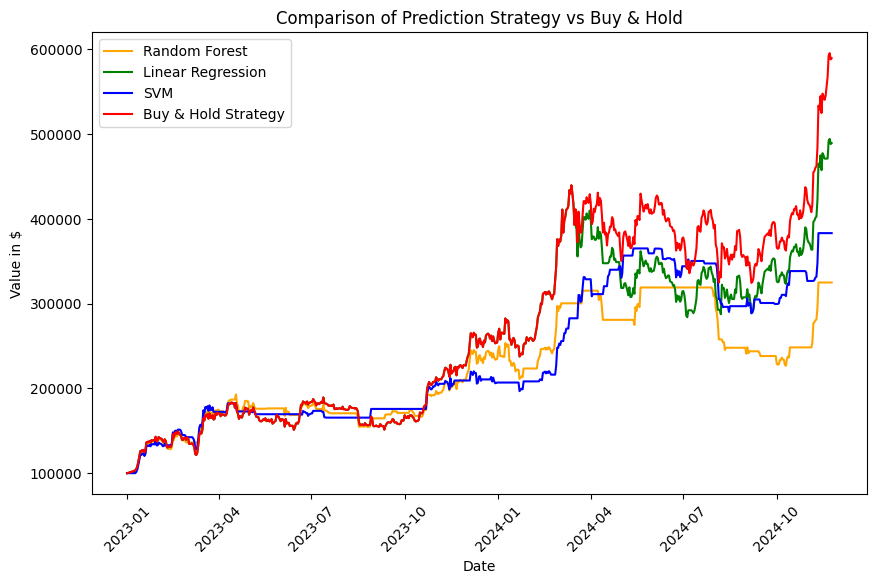

In [30]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=track[0].keys(), y=track[0].values(), label="Random Forest", color="orange")
sns.lineplot(x=track[1].keys(), y=track[1].values(), label="Linear Regression", color="green")
sns.lineplot(x=track[2].keys(), y=track[2].values(), label="SVM", color="blue")
sns.lineplot(x=track_buy_and_hold["date"], y=track_buy_and_hold["value"], label="Buy & Hold Strategy", color="red")
plt.xlabel("Date")
plt.ylabel("Value in $")
plt.title("Comparison of Prediction Strategy vs Buy & Hold")
plt.legend()
plt.xticks(rotation=45)

<h2> Verify Methodology on samples < 2020 </h2>

<t> The peak in 2024 could be a key factor contributing to the poor performance and low R² score. Since the model was trained on data up to 2023, it may struggle to generalize to 2024 if the data deviates significantly from prior trends. This discrepancy suggests that the model is unable to capture the underlying patterns driving the 2024 peak, leading to suboptimal predictions. <t>

In [31]:
df_factors = data[["market cap_MCAP", "close_PRC", "close_MAXDPRC", "r_1", "r_2", "r_3", "r_4", "r_4_1", "volumePRCVOL", "volumeSTDPRCVOL", "DAMIHUD", "7d_return", "close", "date"]]
df_factors.dropna(inplace=True)
verification = df_factors[df_factors["date"] <= "2021-12-31 00:00:00+00:00"]

sample = verification[verification["date"] <= "2019-12-31 00:00:00+00:00"]

out_of_sample = verification[verification["date"] > "2019-12-31 00:00:00+00:00"]

sample.dropna(inplace=True)
out_of_sample.dropna(inplace=True)

/var/folders/sc/fn7t0bc17xsbfl68lnhstkp00000gn/T/ipykernel_92107/440503003.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_factors.dropna(inplace=True)
/var/folders/sc/fn7t0bc17xsbfl68lnhstkp00000gn/T/ipykernel_92107/440503003.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sample.dropna(inplace=True)
/var/folders/sc/fn7t0bc17xsbfl68lnhstkp00000gn/T/ipykernel_92107/440503003.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

In [27]:
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

y = sample.drop(["date", "close"], axis=1)["7d_return"]
X= sample.drop(["7d_return", "date", "close"], axis=1)


pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('rf', RandomForestRegressor(random_state=42))  
])

param_grid = {
    "rf__n_estimators": [50, 100, 200],   
    "rf__max_depth": [5, 10, None],       
    "rf__min_samples_split": [2, 5, 10],  
    "rf__min_samples_leaf": [1, 2, 4]     
}


grid_search = GridSearchCV(
    pipeline, param_grid, cv=tscv, scoring="r2", n_jobs=-1, verbose=2
)


grid_search.fit(X, y)

print("Best Parameters:", grid_search.best_params_)
print("Best R^2 Score:", grid_search.best_score_)
best_model = grid_search.best_estimator_
# Extract the best parameters from GridSearchCV
best_params = grid_search.best_params_

# Train a new pipeline with the best parameters
best_pipeline = Pipeline([
    ('scaler', StandardScaler()),  
    ('rf', RandomForestRegressor(random_state=42, 
                                 n_estimators=best_params["rf__n_estimators"],
                                 max_depth=best_params["rf__max_depth"],
                                 min_samples_split=best_params["rf__min_samples_split"],
                                 min_samples_leaf=best_params["rf__min_samples_leaf"]))  
])

# Fit the new pipeline on the full dataset
best_pipeline.fit(X, y)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.1s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.1s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.2s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=100; total time=   0.2s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.2s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=50; total time=   0.3s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=100; total time=   0.3s
[CV] END rf__max_depth=5, rf__min_samples_leaf=1, rf__min_samples_split=2, rf__n_estimators=100; total time=   0.4s
[CV] END rf__ma

Pipeline(steps=[('scaler', StandardScaler()),
                ('rf',
                 RandomForestRegressor(max_depth=5, min_samples_leaf=4,
                                       min_samples_split=10,
                                       random_state=42))])

In [28]:
cash = 100000
bitcoins = 0
track = {}
for index, row in out_of_sample.iterrows():
    price = row["close"]
    date = row["date"]
    row.drop(["close", "date", "7d_return"], inplace=True)
    expected_return = best_pipeline.predict(pd.DataFrame([row], columns=row.index))
    if expected_return >= 0:
        cash, bitcoins = buy(cash=cash, bitcoins=bitcoins, price=price) 
    elif expected_return < 0:
        cash, bitcoins = sell(cash=cash, bitcoins=bitcoins, price=price)
    #print("cash: " + str(cash) + ", value in bitcoins: " + str(bitcoins * price))
    track[date] = cash + (bitcoins * price)

print("cash: " + str(cash) + ", value in bitcoins: " + str(bitcoins * out_of_sample.iloc[-1]["close"]))

cash: 269298.55062382406, value in bitcoins: 0.0


In [29]:
start_price = out_of_sample.iloc[0]["close"]
end_price = out_of_sample.iloc[-1]["close"]

buy_and_hold_return = (100000 / start_price) * end_price
print(buy_and_hold_return)

643129.5075994141


In [30]:
buy_and_hold_value = out_of_sample.copy(deep=True)
buy_and_hold_value["buy_and_hold"] = buy_and_hold_value["close"] * (100000/start_price)

(array([18262., 18353., 18444., 18536., 18628., 18718., 18809., 18901.,
        18993.]),
 [Text(18262.0, 0, '2020-01'),
  Text(18353.0, 0, '2020-04'),
  Text(18444.0, 0, '2020-07'),
  Text(18536.0, 0, '2020-10'),
  Text(18628.0, 0, '2021-01'),
  Text(18718.0, 0, '2021-04'),
  Text(18809.0, 0, '2021-07'),
  Text(18901.0, 0, '2021-10'),
  Text(18993.0, 0, '2022-01')])

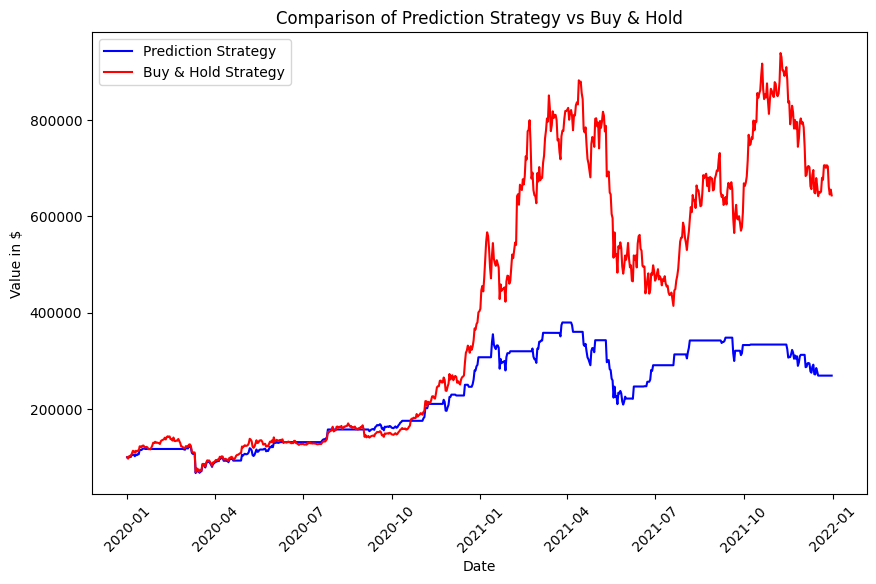

In [31]:
plt.figure(figsize=(10, 6))
sns.lineplot(x=track.keys(), y=track.values(), label="Prediction Strategy", color="blue")
sns.lineplot(x=buy_and_hold_value["date"], y=buy_and_hold_value["buy_and_hold"], label="Buy & Hold Strategy", color="red")

plt.xlabel("Date")
plt.ylabel("Value in $")
plt.title("Comparison of Prediction Strategy vs Buy & Hold")
plt.legend()
plt.xticks(rotation=45)